In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df_july = pd.read_csv("../data/nodalloadweights_4006_202407.csv", skiprows = 3)
df_aug = pd.read_csv("../data/toy.csv")
df = pd.concat([df_july, df_aug])

C:\Users\Dirk\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3165: DtypeWarning: Columns (2,3,5,6,7,8,9) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


In [9]:
df = df[df["Network Node Description"] == "LD.CANDLE  13.2"]
df.reset_index(inplace = True)

In [12]:
df

,index,H,Day,Hour,Location ID,Network Node Description,MW Factor,Energy Component,Congestion Component,Marginal Loss Component,Price
0,84,D,2024-07-01,1,16255,LD.CANDLE 13.2,28.0,25.94,0.0,0.52,26.46
1,177,D,2024-07-01,2,16255,LD.CANDLE 13.2,26.0,28.7,0.0,0.49,29.19
2,270,D,2024-07-01,3,16255,LD.CANDLE 13.2,24.0,23.7,0.0,0.45,24.15
3,363,D,2024-07-01,4,16255,LD.CANDLE 13.2,24.0,23.16,0.0,0.48,23.64
4,456,D,2024-07-01,5,16255,LD.CANDLE 13.2,23.0,24.01,0.0,0.5,24.51
...,...,...,...,...,...,...,...,...,...,...,...
1483,67596,D,2024-08-31,20,16255,LD.CANDLE 13.2,39.0,37.75,0.0,0.92,38.67
1484,67689,D,2024-08-31,21,16255,LD.CANDLE 13.2,38.0,31.37,0.0,0.76,32.13
1485,67782,D,2024-08-31,22,16255,LD.CANDLE 13.2,36.0,27.03,0.0,0.61,27.64
1486,67875,D,2024-08-31,23,16255,LD.CANDLE 13.2,35.0,23.88,0.0,0.5,24.38


In [11]:
df["Hour"] = [int(num) for num in df["Hour"].values]
df["MW Factor"] = [float(num) for num in df["MW Factor"].values]
df["Price"] = [float(num) for num in df["Price"].values]

<ipython-input-11-f2fe98877509>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Hour"] = [int(num) for num in df["Hour"].values]
<ipython-input-11-f2fe98877509>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["MW Factor"] = [float(num) for num in df["MW Factor"].values]
<ipython-input-11-f2fe98877509>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pa

In [24]:
df.to_csv("nantucket.csv")

In [18]:
hm_load = df.pivot(index = "Hour", columns = "Day", values = "MW Factor")
hm_price = df.pivot(index = "Hour", columns = "Day", values = "Price")

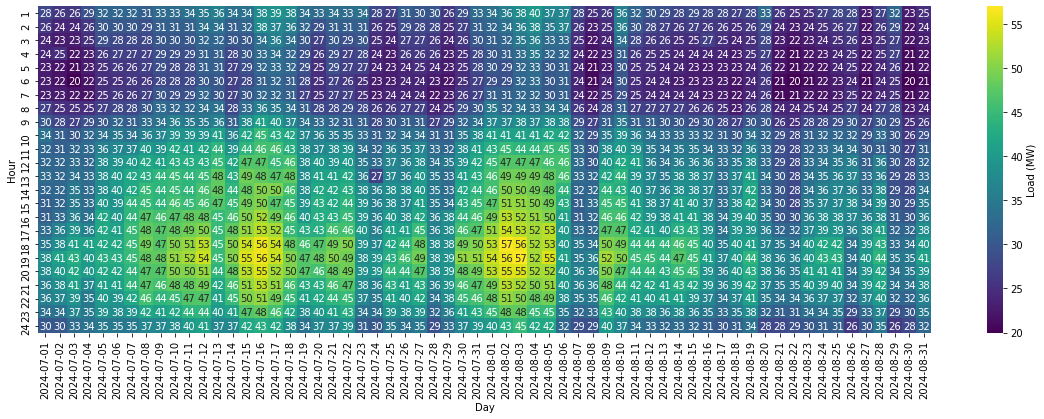

In [21]:
# Plot the heatmap
plt.figure(figsize=(20, 6))
sns.heatmap(hm_load, annot=True, cmap='viridis', cbar_kws={'label': 'Load (MW)'})
# plt.title('Heatmap of Price (August)')
plt.xlabel('Day')
plt.ylabel('Hour')
plt.savefig('load.svg', format='svg')

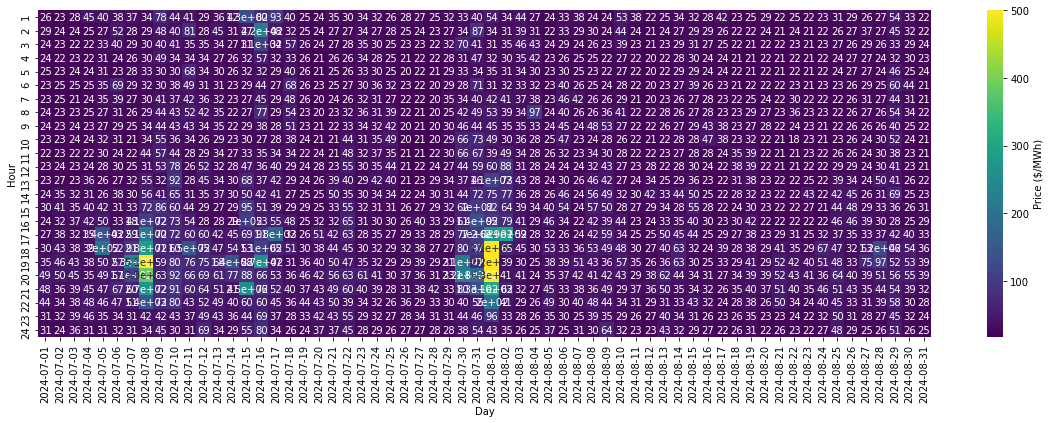

In [23]:
# Plot the heatmap
plt.figure(figsize=(20, 6))
sns.heatmap(hm_price, annot=True, cmap='viridis', cbar_kws={'label': 'Price ($/MWh)'}, vmax = 500)
# plt.title('Heatmap of Price (August)')
plt.xlabel('Day')
plt.ylabel('Hour')
plt.savefig('price.svg', format='svg')

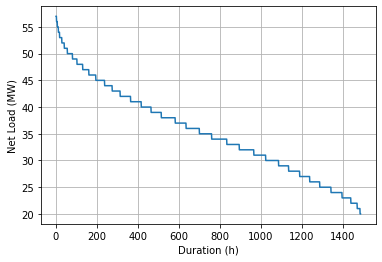

In [55]:
# Plot load duration curve
plt.plot(1 + np.arange(len(df)), df["MW Factor"].sort_values(ascending = False))
plt.grid()
plt.xlabel('Duration (h)')
plt.ylabel('Net Load (MW)')
plt.savefig('loadduration.svg', format='svg')

In [49]:
# N-1 Shortfall reduction as a function of storage size in the absence of current storage
y = np.arange(11)
xmax = 51
phi = np.zeros(len(y))
for i in y:
    phi[i] = sum(np.maximum(df["MW Factor"] - xmax - i, 0))

In [50]:
phi

array([104.,  64.,  36.,  19.,   8.,   2.,   0.,   0.,   0.,   0.,   0.])

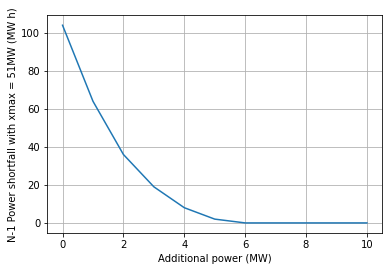

In [54]:
plt.plot(y, phi)
plt.grid()
plt.xlabel('Additional power (MW)')
plt.ylabel('N-1 Power shortfall with xmax = 51MW (MW h)')
plt.savefig('powershortfall.svg', format='svg')